# `qufin.wyckoff` Tutorial

An end-to-end walkthrough of the **wyckoff** subpackage: a quantitative toolkit
for Wyckoff-method market analysis, applied to *real* market data.

This notebook doubles as a primer on the **Wyckoff method** itself. The next
few cells lay out the theory — composite operator, the three laws, the
accumulation and distribution schematics, and the canonical events that
mark each phase. The rest of the notebook then turns each piece of theory
into code, applied to real bars pulled with `yfinance`.

**Sections**

1. Bar primitives — `OHLCV`, validation, true range, ATR, rolling z-scores
2. Swing-point detection — fractal pivots and percent-reversal ZigZag
3. Trading-range detection — finding lateral consolidations
4. Volume profile — POC, value area, anchored VWAP
5. Effort vs Result — quantifying absorption
6. Schematic event detection — SC, AR, ST, Spring, SOS, LPS
7. Rule-based phase classification (Phases A–E)
8. HMM-based macro-phase classification (Accumulation / Markup / Distribution / Markdown)
9. Point-and-figure with cause-and-effect price targets
10. Wyckoff-style relative strength


## Wyckoff theory, in depth

The Wyckoff method was formalised by Richard D. Wyckoff in the late 1920s and
1930s, drawing on his own tape-reading career and on conversations with the
great operators of his era (Jesse Livermore, James Keene, …). It is a
*structural* approach to markets: rather than predicting price from a
mathematical model, it reads price and volume as the footprints of large
operators and infers where in the *campaign cycle* the market currently is.

### The Composite Operator

Wyckoff's central abstraction is the **Composite Operator** (CO) — a
hypothetical, perfectly-informed institution that *causes* market trends.
Treating the aggregate behaviour of all professional money as a single
operator is a useful fiction: it gives every market structure a teleology
(“the CO is now testing supply”) and converts pattern recognition into
narrative reading.

A campaign in the CO's mind goes like this:

1. **Accumulate** — buy quietly inside a sideways range while the public
   panics out of the prior down-leg. Average price is concealed by chop.
2. **Mark up** — once supply at higher prices has been absorbed, drive
   price up with little resistance to attract retail demand.
3. **Distribute** — sell into that retail demand inside a new sideways
   range near the highs.
4. **Mark down** — once distribution is complete, walk price down,
   inducing retail to sell at progressively lower prices.

Everything else in Wyckoff is an attempt to spot *where in this cycle*
you are, by reading **price action, volume, and the relationship between
the two**.


### The Three Laws

The whole method reduces to three laws.

**1. Supply & Demand.** Price rises when demand exceeds supply and falls when
supply exceeds demand. This sounds tautological — but it forces you to read
every bar as a *transaction* between two sides, not as a number on a chart.
A wide-range up bar on high volume means heavy buying overpowered sellers;
the same bar on low volume means the rise found no resistance and therefore
proves little.

**2. Cause & Effect.** A move in price requires a *cause* of accumulation or
distribution that preceded it. Long ranges produce long trends; short ranges
produce short trends. Point-and-figure counts (covered later) quantify this:
the *width* of a base in P&F columns is the cause; the projected *height* of
the breakout is the effect.

**3. Effort vs Result.** Effort is volume. Result is the price progress made
on that volume. When effort is large and result is small — a wide volume
bar that closes near where it opened — supply (or demand) is being
*absorbed* by the other side. Absorption is the most important
micro-structural footprint in Wyckoff: it tells you the CO is taking the
other side of the obvious move.


### The four macro phases

Every chart, at every timeframe, is in exactly one of four macro states:

| Phase | Slope | Volume signature | Operator action |
|---|---|---|---|
| **Accumulation** | flat | climactic at the lows, then dries up | buying inside the range |
| **Markup** | rising | high on breakouts, lighter on pullbacks | letting price run; selling on strength |
| **Distribution** | flat | climactic at the highs, then dries up | selling inside the range |
| **Markdown** | falling | high on breakdowns, lighter on rallies | letting price fall; covering on weakness |

The transitions between phases are where the money is made. The **rule-based
phase classifier** in this package handles the *within-range structure* of an
accumulation or distribution (sub-phases A through E). The **HMM macro
classifier** handles the *cycle-level* assignment across the whole chart.
We use both later in the notebook.


### The accumulation schematic — Phases A–E

Inside a single accumulation range, Wyckoff partitions time into five
sub-phases:

* **Phase A — Stopping action.** The prior down-leg ends. The four
  canonical events are *PS* (Preliminary Support, the first absorption bar
  in the decline), *SC* (Selling Climax, the panic-volume bar that prints
  the range low), *AR* (Automatic Rally, the snap-back that defines range
  resistance), and *ST* (Secondary Test, a return to the SC area on
  lighter volume).
* **Phase B — Building the cause.** Price oscillates between range
  support and resistance. The CO is buying on dips and selling rallies
  to thin out the float. Volume gradually contracts.
* **Phase C — Test of supply.** The decisive test. A **Spring** is a
  brief breakdown below support that gets bid back into the range —
  it shakes out the last weak holders and confirms there is no more
  supply at the lows.
* **Phase D — Markup begins.** Demand now dominates. A **SOS** (Sign
  of Strength) is a wide-range, high-volume bar that closes *above*
  range resistance. The subsequent **LPS** (Last Point of Support) is
  a low-volume pullback that holds above resistance — the last
  good long entry inside the schematic.
* **Phase E — Out of the range.** The markup is underway. Price
  trends; pullbacks find support at successive prior LPS levels.

These five phases and the events inside them are exactly what the
detectors in `qufin.wyckoff.events` and the classifier in
`qufin.wyckoff.phases` look for.


### The distribution schematic — the mirror image

Distribution is the dual of accumulation. The same five phases occur,
labelled with mirror-image events:

| Accumulation | ↔ | Distribution |
|---|---|---|
| Selling Climax (SC) | ↔ | Buying Climax (BC) |
| Automatic Rally (AR) | ↔ | Automatic Reaction (still labelled AR) |
| Secondary Test (ST) | ↔ | ST (in the high) |
| Spring | ↔ | Upthrust (UT) / UTAD |
| Sign of Strength (SOS) | ↔ | Sign of Weakness (SOW) |
| Last Point of Support (LPS) | ↔ | Last Point of Supply (LPSY) |

The detectors for the distribution side live in the same module
(`detect_upthrust`, `detect_sow_lpsy`). The rule-based phase classifier
handles both schematics symmetrically.


### Events glossary

| Code | Name | Meaning |
|---|---|---|
| **PS** | Preliminary Support | First absorption bar on the down-leg |
| **SC** | Selling Climax | Panic-volume capitulation; range low |
| **AR** | Automatic Rally | Snap-back off the SC; defines resistance |
| **ST** | Secondary Test | Retest of SC on lighter volume |
| **Spring** | Spring | False break of range support that recovers |
| **Test** | Test | Second, low-volume probe of the Spring low |
| **SOS** | Sign of Strength | Wide-range, high-volume breakout |
| **LPS** | Last Point of Support | Low-volume pullback after SOS |
| **BC** | Buying Climax | The SC equivalent at a top |
| **UT** | Upthrust | False break above range resistance |
| **UTAD** | Upthrust After Distribution | UT that follows an SOW |
| **SOW** | Sign of Weakness | Wide-range, high-volume breakdown |
| **LPSY** | Last Point of Supply | Weak rally after SOW |

In the cells that follow we pull a real chart and let the package
identify these events automatically.


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import yfinance as yf

from qufin.wyckoff import (
    OHLCV,
    TradingRange,
    WyckoffHMMClassifier,
    anchored_vwap,
    atr,
    classify_phases,
    detect_automatic_rally,
    detect_climax,
    detect_secondary_test,
    detect_sos_lps,
    detect_spring,
    detect_trading_ranges,
    effort_vs_result,
    find_swings,
    horizontal_count,
    pnf_from_bars,
    relative_strength,
    rs_rank,
    true_range,
    vertical_count,
    volume_profile,
    zigzag,
)

plt.rcParams.update({
    'figure.figsize': (13, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLOR_UP = '#1f8e3a'
COLOR_DN = '#c4302b'


def load_ohlcv(ticker: str, start: str, end: str, interval: str = '1d') -> OHLCV:
    """Pull bars from yfinance and coerce them into a Wyckoff OHLCV frame."""
    raw = yf.download(
        ticker, start=start, end=end, interval=interval,
        auto_adjust=False, progress=False,
    )
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw = raw.reset_index()
    ts_col = 'Datetime' if 'Datetime' in raw.columns else 'Date'
    ts = pd.to_datetime(raw[ts_col])
    ts = ts.dt.tz_localize('UTC') if ts.dt.tz is None else ts.dt.tz_convert('UTC')
    pdf = pd.DataFrame({
        'timestamp': ts,
        'open': raw['Open'].astype('float64'),
        'high': raw['High'].astype('float64'),
        'low': raw['Low'].astype('float64'),
        'close': raw['Close'].astype('float64'),
        'volume': raw['Volume'].astype('float64'),
    }).dropna()
    return OHLCV.from_records(pl.from_pandas(pdf), symbol=ticker)


def plot_ohlc(
    ax: plt.Axes,
    bars: OHLCV,
    *,
    width: float = 0.7,
    color_up: str = COLOR_UP,
    color_down: str = COLOR_DN,
) -> None:
    """Classic Western OHLC bar chart: vertical wick + left/right tick for O/C."""
    o, h, l, c = bars.open(), bars.high(), bars.low(), bars.close()
    x = np.arange(o.shape[0])
    up = c >= o
    dn = ~up
    half = width / 2.0
    for mask, color in ((up, color_up), (dn, color_down)):
        ax.vlines(x[mask], l[mask], h[mask], color=color, lw=0.8)
        ax.hlines(o[mask], x[mask] - half, x[mask], color=color, lw=0.8)
        ax.hlines(c[mask], x[mask], x[mask] + half, color=color, lw=0.8)


def plot_volume(ax: plt.Axes, bars: OHLCV, *, width: float = 0.85) -> None:
    """Volume bar chart, coloured up/down on bar direction."""
    o, c, v = bars.open(), bars.close(), bars.volume()
    x = np.arange(v.shape[0])
    colors = np.where(c >= o, COLOR_UP, COLOR_DN)
    ax.bar(x, v, color=colors, width=width, alpha=0.7)


## 0. Load real data — NVDA daily bars

We pull NVIDIA daily bars from early 2022 to mid-2024 with `yfinance`.
This window is long enough to contain a textbook campaign cycle:
the 2022 bear market provides a clean **Selling Climax**, the
sideways structure into early 2023 builds a multi-month
**accumulation range**, the AI-driven move from mid-2023 onwards is
a textbook **Markup**, and the lateral structure into mid-2024 looks
like the early phases of a possible Distribution.

If yfinance times out or returns nothing (e.g. offline), point the loader
at any local CSV/Parquet file with the same columns — every detector
in this notebook then runs unchanged.


In [ ]:
bars = load_ohlcv('NVDA', start='2022-01-01', end='2024-07-01')
print(f'{len(bars)} bars, symbol={bars.symbol}')
print(
    f'date range: {bars.data["timestamp"].min()}  '
    f'→  {bars.data["timestamp"].max()}'
)
bars.data.head(3)


452 bars, symbol=BTC
date range: 2024-07-31 00:00:00+00:00  →  2026-05-19 00:00:00+00:00


timestamp,open,high,low,close,volume
"datetime[ns, UTC]",f64,f64,f64,f64,f64
2024-07-31 00:00:00 UTC,29.5,29.65,28.799999,28.950001,930940.0
2024-08-01 00:00:00 UTC,28.65,28.799999,27.6,28.1,8.5645e6
2024-08-02 00:00:00 UTC,28.75,29.049999,27.65,27.799999,2.41256e6


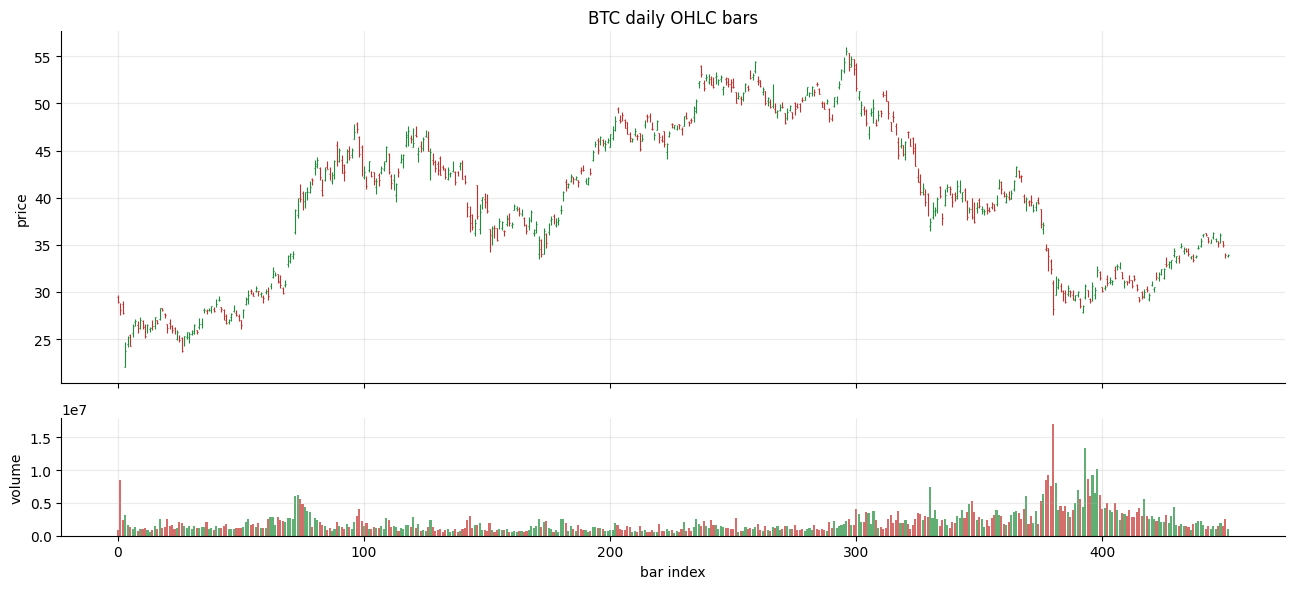

In [20]:
fig, (ax_p, ax_v) = plt.subplots(
    2, 1, sharex=True, height_ratios=[3, 1], figsize=(13, 6),
)
plot_ohlc(ax_p, bars)
ax_p.set_title(f'{bars.symbol} daily OHLC bars')
ax_p.set_ylabel('price')
plot_volume(ax_v, bars)
ax_v.set_ylabel('volume')
ax_v.set_xlabel('bar index')
plt.tight_layout()
plt.show()


## 1. Bar primitives — true range, ATR, rolling z-scores

`OHLCV` is a thin polars wrapper enforcing the canonical schema. The
bar-level helpers are numba-jitted and return float64 numpy arrays.

* `true_range(bars)` — Wilder's TR per bar.
* `atr(bars, window=14)` — Wilder-smoothed ATR; the first `window-1`
  entries are NaN by design.
* `normalize_volume(bars, window=50)` — rolling z-score of volume;
  the input to every climax/SOS detector.


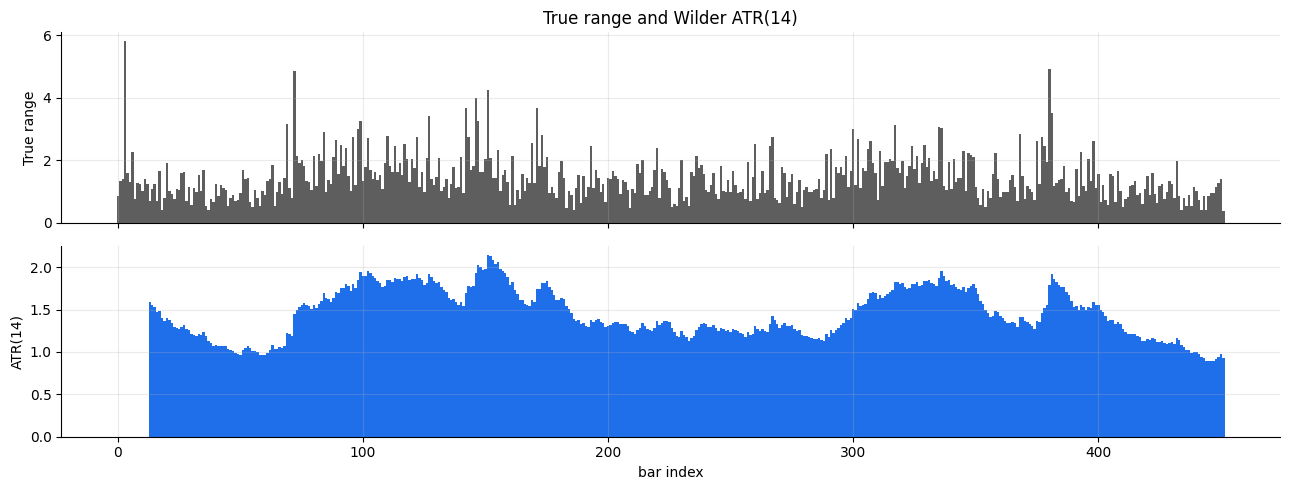

In [21]:
tr = true_range(bars)
a = atr(bars, window=14)

fig, (ax_tr, ax_atr) = plt.subplots(2, 1, sharex=True, figsize=(13, 5))
x = np.arange(len(bars))
ax_tr.bar(x, tr, color='#5e5e5e', width=1.0)
ax_tr.set_ylabel('True range')
ax_tr.set_title('True range and Wilder ATR(14)')
ax_atr.bar(x, a, color='#1f6feb', width=1.0)
ax_atr.set_ylabel('ATR(14)')
ax_atr.set_xlabel('bar index')
plt.tight_layout()
plt.show()


## 2. Swing-point detection

Two algorithms for marking pivots:

* **Fractal swings** (`find_swings`) — Bill-Williams style. A bar is a
  swing high iff its `high` strictly exceeds the highs of the `left` bars
  before and the `right` bars after.
* **ZigZag** (`zigzag`) — emits a pivot only after a counter-move of
  at least `pct`. Good for noisy series.

Both return a list of `SwingPoint` dataclasses
(`idx`, `timestamp`, `price`, `kind`, `strength`).


51 fractal swings, 51 zigzag pivots


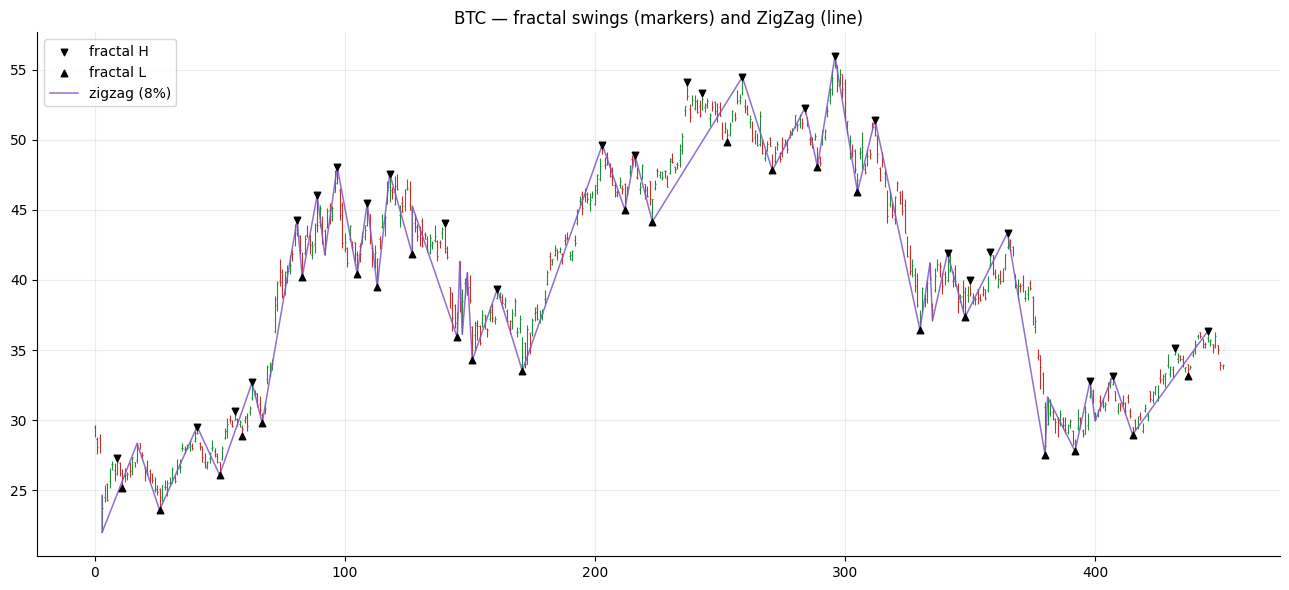

In [22]:
fractals = find_swings(bars, left=5, right=5)
zz = zigzag(bars, pct=0.08)
print(f'{len(fractals)} fractal swings, {len(zz)} zigzag pivots')

fig, ax = plt.subplots(figsize=(13, 6))
plot_ohlc(ax, bars)
fr_h = [s for s in fractals if s.kind == 'H']
fr_l = [s for s in fractals if s.kind == 'L']
ax.scatter([s.idx for s in fr_h], [s.price for s in fr_h],
           marker='v', color='black', s=22, zorder=4, label='fractal H')
ax.scatter([s.idx for s in fr_l], [s.price for s in fr_l],
           marker='^', color='black', s=22, zorder=4, label='fractal L')
ax.plot([s.idx for s in zz], [s.price for s in zz],
        color='#7e57c2', lw=1.1, alpha=0.85, label='zigzag (8%)')
ax.set_title(f'{bars.symbol} — fractal swings (markers) and ZigZag (line)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


## 3. Trading-range detection

`detect_trading_ranges` slides a window over the bars and flags segments
whose price extreme is narrow relative to local ATR. Overlapping
qualifying windows are merged into the longest contiguous run.

In Wyckoff terms a trading range is the *site of a campaign* — every
detector that follows (climaxes inside the range, springs, breakouts)
operates relative to one.


TradingRange  bars [  0, 452)  support=22.00  resistance=55.96  width=33.96


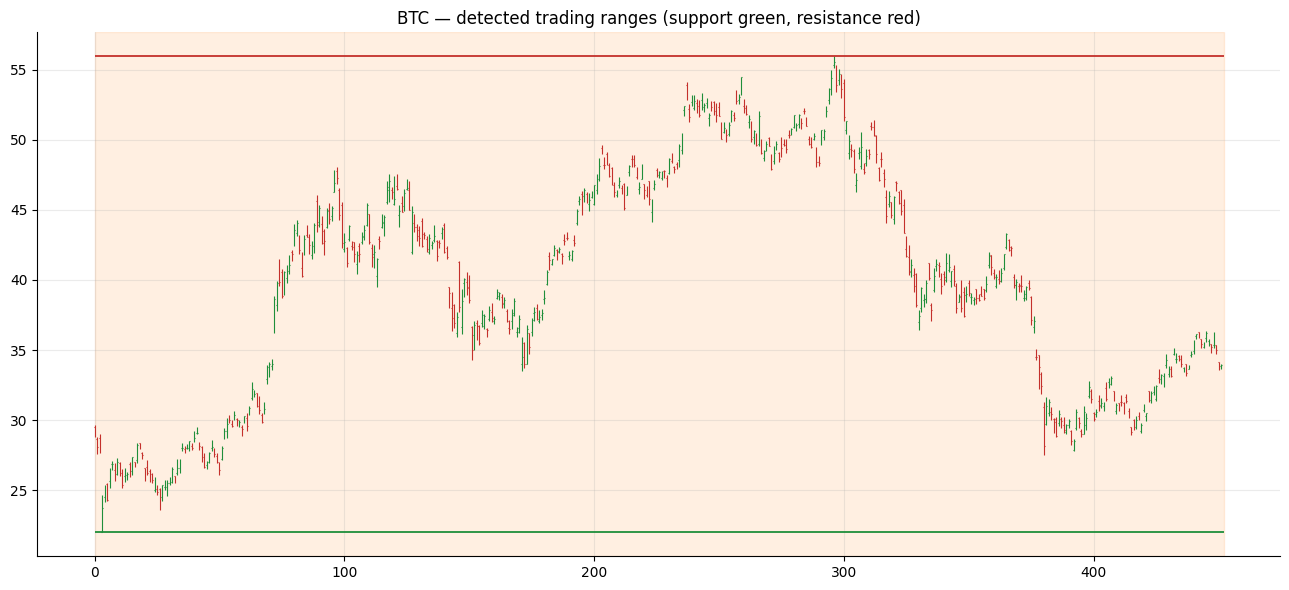

In [23]:
ranges = detect_trading_ranges(bars, min_bars=25, max_width_atr=8.0)
for r in ranges:
    print(
        f'TradingRange  bars [{r.start_idx:3d}, {r.end_idx:3d})  '
        f'support={r.support:.2f}  resistance={r.resistance:.2f}  '
        f'width={r.width:.2f}'
    )

fig, ax = plt.subplots(figsize=(13, 6))
plot_ohlc(ax, bars)
for r in ranges:
    ax.axvspan(r.start_idx, r.end_idx, alpha=0.12, color='C1')
    ax.hlines(r.support, r.start_idx, r.end_idx, color=COLOR_UP, lw=1.3)
    ax.hlines(r.resistance, r.start_idx, r.end_idx, color=COLOR_DN, lw=1.3)
ax.set_title(f'{bars.symbol} — detected trading ranges (support green, resistance red)')
plt.tight_layout()
plt.show()


## 4. Volume profile and anchored VWAP

`volume_profile` distributes each bar's volume uniformly across its
high-low range, then

* picks the **POC** (Point of Control) — the bin centre with the
  most volume;
* widens out from the POC until 70% of total volume is captured —
  that band is the **value area** (VAL / VAH);
* identifies **HVN** / **LVN** as local maxima / minima of the
  histogram.

`anchored_vwap` computes a running VWAP from any chosen anchor bar —
typically a climax, a spring, or the start of a new session.


POC=17.14   VAL=10.81   VAH=31.52


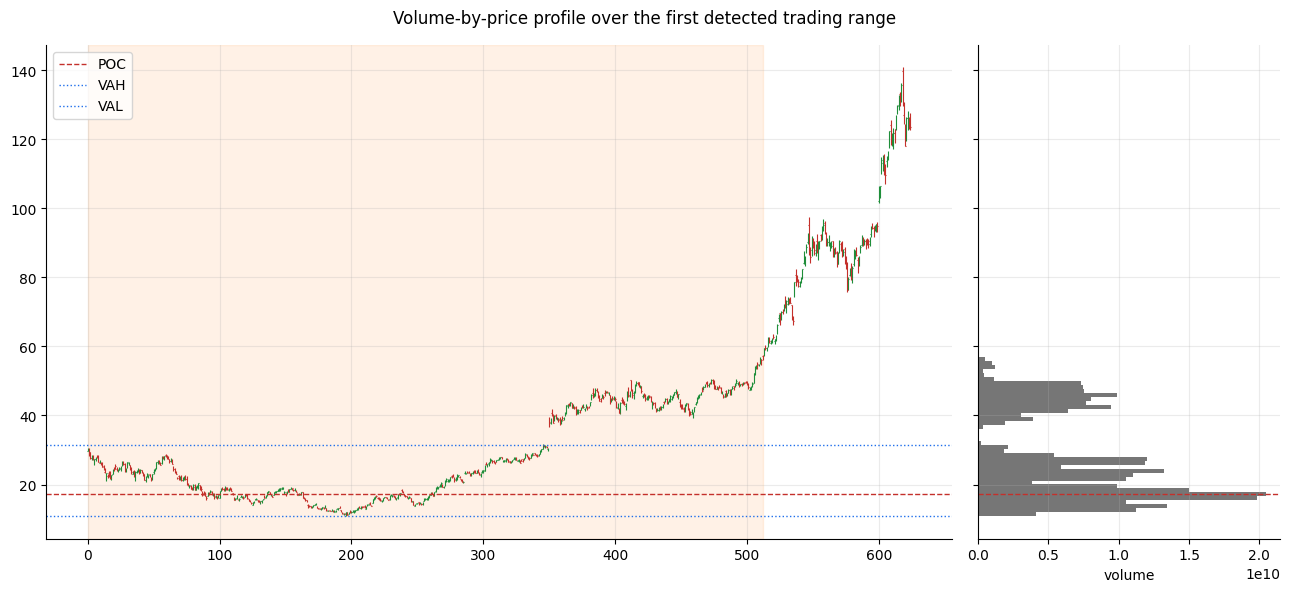

In [7]:
if ranges:
    rng_first = ranges[0]
else:
    rng_first = TradingRange(
        start_idx=0, end_idx=len(bars),
        support=float(bars.low().min()),
        resistance=float(bars.high().max()),
    )

profile = volume_profile(
    bars, n_bins=40, start=rng_first.start_idx, end=rng_first.end_idx,
)
print(f'POC={profile.poc:.2f}   VAL={profile.val:.2f}   VAH={profile.vah:.2f}')

fig, (ax_px, ax_vp) = plt.subplots(
    1, 2, sharey=True, figsize=(13, 6), width_ratios=[3, 1],
)
plot_ohlc(ax_px, bars)
ax_px.axvspan(rng_first.start_idx, rng_first.end_idx, alpha=0.10, color='C1')
ax_px.axhline(profile.poc, color=COLOR_DN, ls='--', lw=1.0, label='POC')
ax_px.axhline(profile.vah, color='#1f6feb', ls=':', lw=1.0, label='VAH')
ax_px.axhline(profile.val, color='#1f6feb', ls=':', lw=1.0, label='VAL')
ax_px.legend(loc='upper left')
centres = 0.5 * (profile.price_bins[:-1] + profile.price_bins[1:])
ax_vp.barh(centres, profile.volume, height=np.diff(profile.price_bins),
           color='#5e5e5e', alpha=0.85)
ax_vp.axhline(profile.poc, color=COLOR_DN, ls='--', lw=1.0)
ax_vp.set_xlabel('volume')
plt.suptitle('Volume-by-price profile over the first detected trading range')
plt.tight_layout()
plt.show()


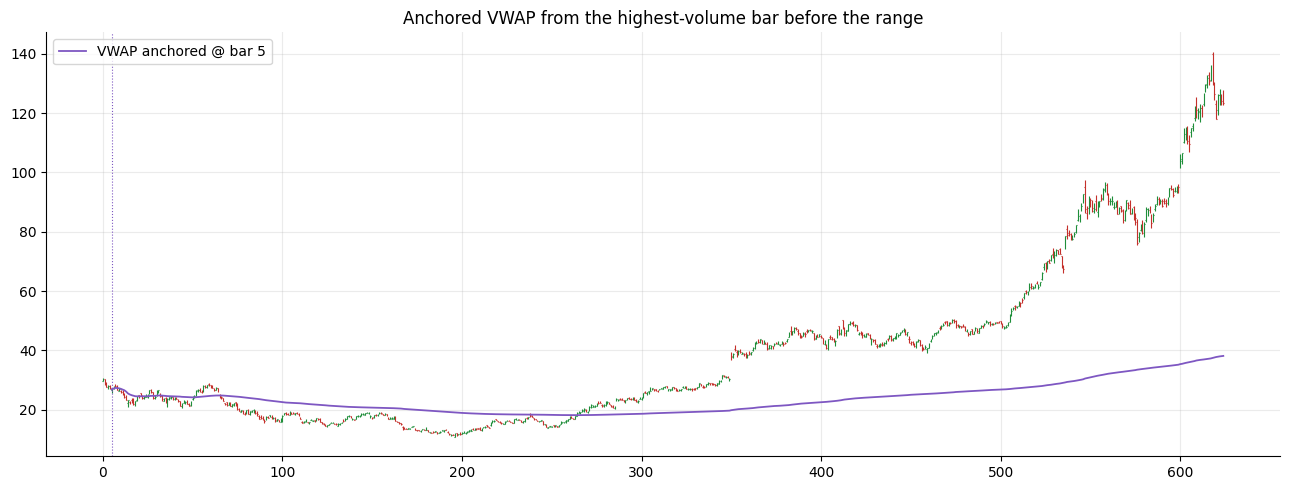

In [8]:
# Anchor the VWAP at the highest-volume bar in the early portion of the
# series — a reasonable proxy for “where the operator started buying”.
k_anchor = int(np.argmax(bars.volume()[: rng_first.start_idx + 10]))
vwap = anchored_vwap(bars, anchor_idx=k_anchor)

fig, ax = plt.subplots(figsize=(13, 5))
plot_ohlc(ax, bars)
ax.plot(vwap, color='#7e57c2', lw=1.3, label=f'VWAP anchored @ bar {k_anchor}')
ax.axvline(k_anchor, color='#7e57c2', ls=':', lw=0.8)
ax.set_title('Anchored VWAP from the highest-volume bar before the range')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


## 5. Effort vs Result

Wyckoff's third law: a *bullish absorption bar* shows heavy **effort**
(volume) with little downward **result** (body relative to true range).
It signals supply being absorbed by larger demand.

We compute rolling z-scores of `log(volume)` and `|close-open|/TR` and
flag bars where effort is high but result is low.


16 absorption bars flagged


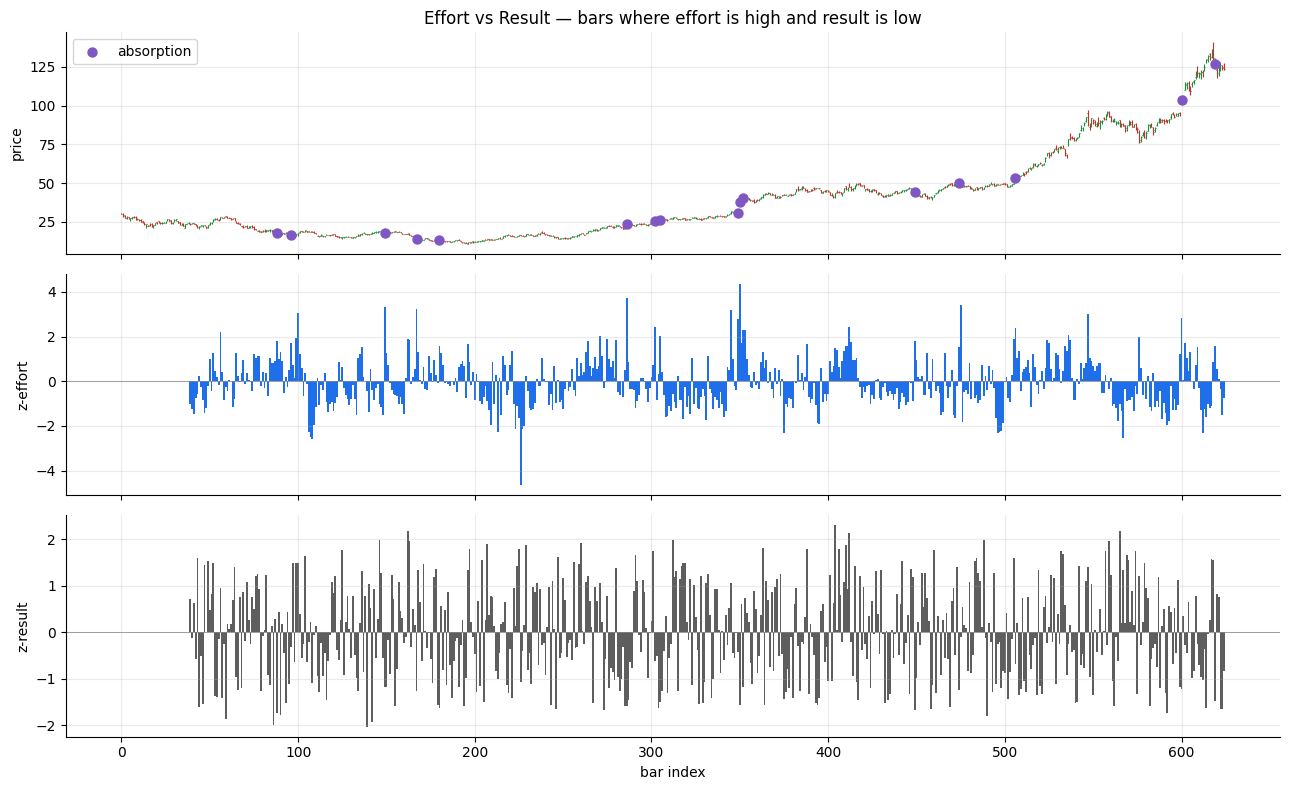

In [10]:
er = effort_vs_result(bars, window=40, effort_z=1.5, result_z=-0.3)
flagged = np.where(er.flag_absorption)[0]
print(f'{len(flagged)} absorption bars flagged')

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(13, 8))
plot_ohlc(axes[0], bars)
axes[0].scatter(flagged, bars.close()[flagged], color='#7e57c2',
                marker='o', s=42, zorder=5, label='absorption')
axes[0].set_ylabel('price')
axes[0].legend(loc='upper left')

x = np.arange(len(bars))
axes[1].bar(x, er.z_effort, color='#1f6feb', width=1.0)
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_ylabel('z-effort')

axes[2].bar(x, er.z_result, color='#5e5e5e', width=1.0)
axes[2].axhline(0, color='gray', lw=0.5)
axes[2].set_ylabel('z-result')
axes[2].set_xlabel('bar index')

axes[0].set_title('Effort vs Result — bars where effort is high and result is low')
plt.tight_layout()
plt.show()


## 6. Schematic event detection — SC, AR, ST, Spring, SOS, LPS

Every detector is deterministic and threshold-based. Defaults follow
standard Wyckoff heuristics; every threshold is a keyword argument so
you can tune for timeframe and asset.

We work with the first detected trading range. From the climaxes inside
the range we walk the schematic step-by-step: climax → automatic rally
→ secondary test → spring (if any) → SOS → LPS.


In [11]:
climaxes = detect_climax(
    bars, vol_window=40, trend_window=20, z_volume=1.8, z_range=1.2,
)
for c in climaxes:
    print(
        f'{c.kind} @ bar {c.idx}  z_vol={c.z_volume:.2f}  '
        f'z_rng={c.z_range:.2f}  price={c.price:.2f}'
    )

sc = next((c for c in climaxes if c.kind == 'SC'), None)
ar = detect_automatic_rally(bars, sc, max_bars=30) if sc is not None else None
st = (
    detect_secondary_test(bars, sc, ar, tolerance_atr=2.0, max_bars=60)
    if (sc is not None and ar is not None) else None
)
print(f'SC: {sc}')
print(f'AR: {ar}')
print(f'ST: {st}')


SC @ bar 100  z_vol=3.68  z_rng=2.30  price=16.02
SC @ bar 162  z_vol=1.95  z_rng=2.15  price=16.83
BC @ bar 305  z_vol=1.96  z_rng=1.48  price=27.59
BC @ bar 352  z_vol=2.11  z_rng=2.53  price=41.94
BC @ bar 353  z_vol=2.24  z_rng=3.08  price=40.29
BC @ bar 537  z_vol=2.23  z_rng=2.66  price=82.39
BC @ bar 547  z_vol=3.87  z_rng=5.07  price=97.40
SC: ClimaxEvent(idx=100, kind='SC', z_volume=3.6754859292711983, z_range=2.2969690603717385, price=16.02199935913086)
AR: StructuralEvent(idx=104, kind='AR', price=19.618999481201172, z_volume=0.43035702459122205)
ST: StructuralEvent(idx=105, kind='ST', price=18.52199935913086, z_volume=-0.02820925134749778)


In [12]:
springs = detect_spring(
    bars, rng_first, max_penetration_atr=3.0, recovery_bars=5,
)
sos, lps = detect_sos_lps(
    bars, rng_first,
    breakout_z_volume=1.0, breakout_z_range=1.0, lookahead=30,
)
print(f'{len(springs)} spring(s)   {len(sos)} SOS   {len(lps)} LPS')
for s in springs:
    print(
        f'  Spring @ bar {s.idx}  pen={s.penetration:.2f}  '
        f'recovery={s.recovery_bars} bars'
    )
for s in sos:
    print(f'  SOS    @ bar {s.idx}  z_vol={s.z_volume:.2f}  price={s.price:.2f}')
for s in lps:
    print(f'  LPS    @ bar {s.idx}  z_vol={s.z_volume:.2f}  price={s.price:.2f}')


0 spring(s)   9 SOS   0 LPS
  SOS    @ bar 516  z_vol=1.08  price=61.36
  SOS    @ bar 524  z_vol=1.95  price=69.33
  SOS    @ bar 525  z_vol=2.23  price=68.22
  SOS    @ bar 529  z_vol=1.53  price=72.25
  SOS    @ bar 530  z_vol=1.40  price=72.13
  SOS    @ bar 534  z_vol=2.08  price=69.45
  SOS    @ bar 535  z_vol=1.73  price=67.47
  SOS    @ bar 536  z_vol=2.90  price=78.54
  SOS    @ bar 537  z_vol=2.44  price=78.82


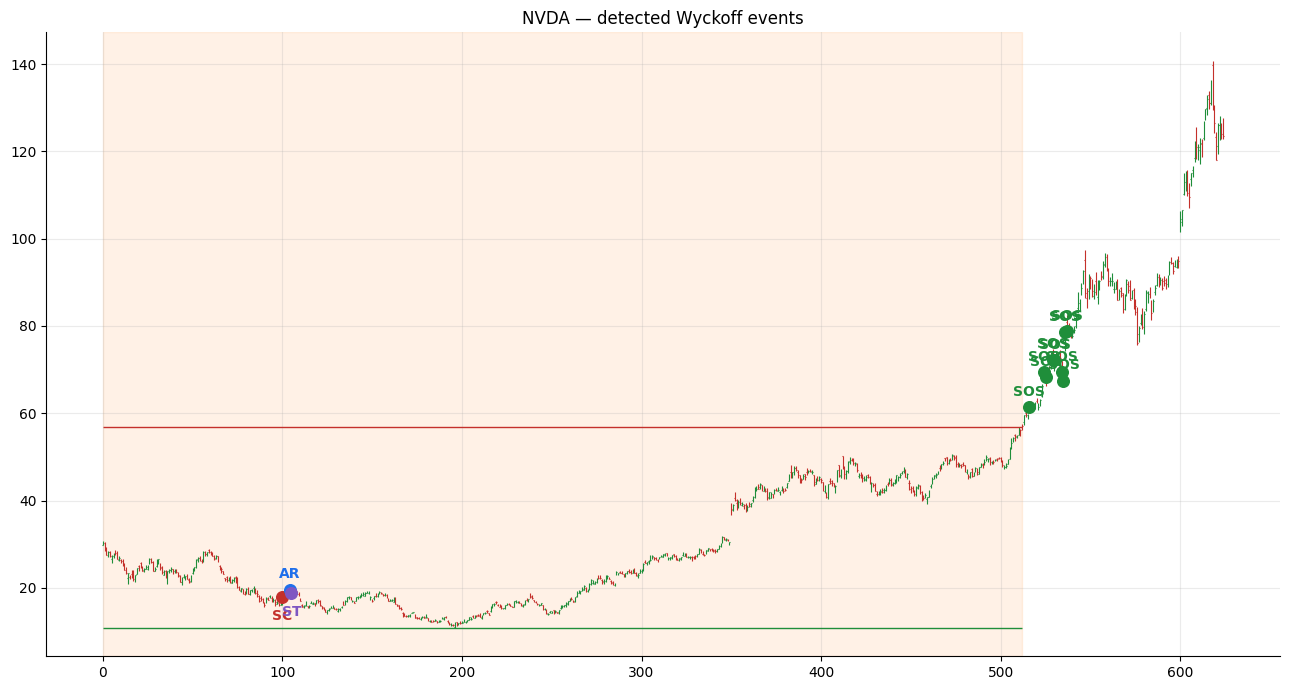

In [13]:
fig, ax = plt.subplots(figsize=(13, 7))
plot_ohlc(ax, bars)
ax.axvspan(rng_first.start_idx, rng_first.end_idx, alpha=0.10, color='C1')
ax.hlines(rng_first.support, rng_first.start_idx, rng_first.end_idx,
          color=COLOR_UP, lw=1.0)
ax.hlines(rng_first.resistance, rng_first.start_idx, rng_first.end_idx,
          color=COLOR_DN, lw=1.0)


def annot(idx: int, label: str, color: str, dy: float = 5.0) -> None:
    px = float(bars.close()[idx])
    ax.scatter([idx], [px], color=color, s=70, zorder=5)
    ax.annotate(label, (idx, px), xytext=(idx, px + dy),
                fontsize=10, ha='center', color=color, fontweight='bold')


span = float(bars.high().max() - bars.low().min())
dy = 0.02 * span

if sc is not None:
    annot(sc.idx, 'SC', COLOR_DN, dy=-2 * dy)
if ar is not None:
    annot(ar.idx, 'AR', '#1f6feb', dy=dy)
if st is not None:
    annot(st.idx, 'ST', '#7e57c2', dy=-2 * dy)
for s in springs:
    annot(s.idx, 'Spring', '#ff9800', dy=-2 * dy)
for s in sos:
    annot(s.idx, 'SOS', COLOR_UP, dy=dy)
for s in lps:
    annot(s.idx, 'LPS', '#00897b', dy=-dy)

ax.set_title(f'{bars.symbol} — detected Wyckoff events')
plt.tight_layout()
plt.show()


## 7. Rule-based phase classification (A → E)

Given the events above, `classify_phases` walks them in chronological
order per trading range and labels each segment Phase A through E:

* **Phase A** — stopping action (PS / SC / AR / ST).
* **Phase B** — building the cause (oscillation between AR-high and
  ST-low).
* **Phase C** — test of supply (Spring) or test of demand (UTAD).
* **Phase D** — markup/markdown developing (SOS-LPS or SOW-LPSY).
* **Phase E** — range exit confirmed.


  Acc Phase A: bars [0, 106)
  Acc Phase B: bars [106, 512)
  Acc Phase D: bars [516, 538)
  Acc Phase E: bars [538, 625)


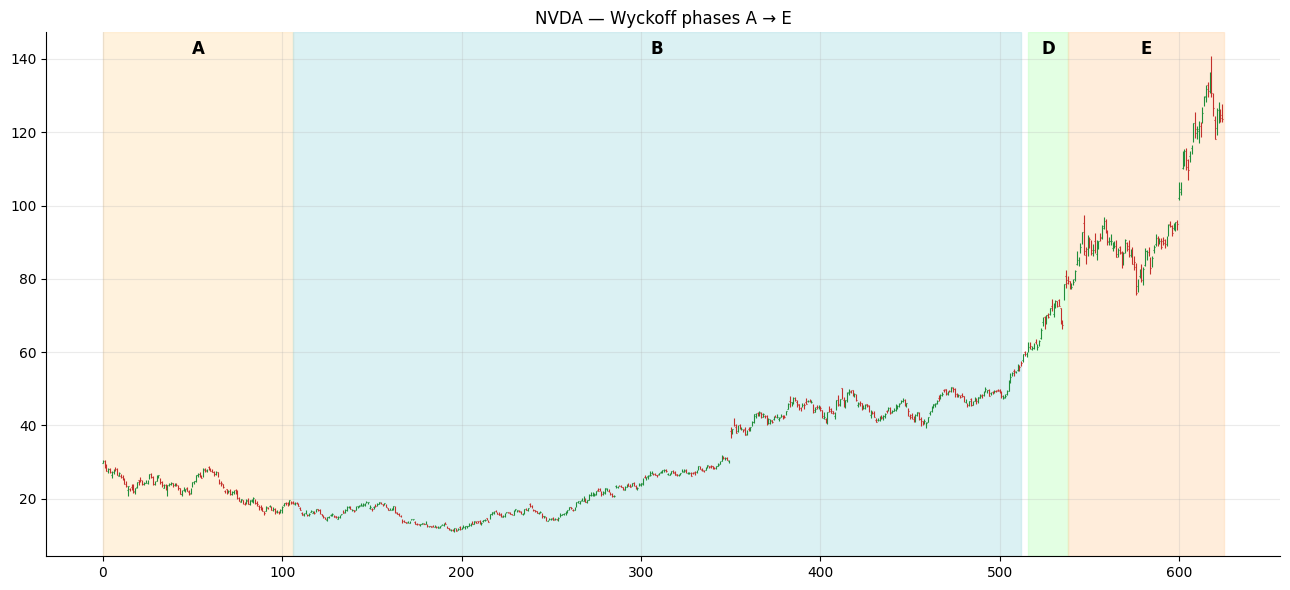

In [14]:
structural_events: list = []
if ar is not None:
    structural_events.append(ar)
if st is not None:
    structural_events.append(st)
structural_events.extend(sos)
structural_events.extend(lps)

phases = classify_phases(bars, [rng_first], climaxes, structural_events, springs)
for p in phases:
    print(f'  {p.schematic} Phase {p.phase}: bars [{p.start_idx}, {p.end_idx})')

fig, ax = plt.subplots(figsize=(13, 6))
plot_ohlc(ax, bars)
ph_colors = {'A': '#FFE4B5', 'B': '#B0E0E6', 'C': '#F5DEB3',
             'D': '#C1FFC1', 'E': '#FFD8B1'}
y_top = bars.high().max()
for p in phases:
    ax.axvspan(p.start_idx, p.end_idx, alpha=0.45,
               color=ph_colors.get(p.phase, '#DDD'))
    mid = 0.5 * (p.start_idx + p.end_idx)
    ax.text(mid, y_top * 1.005, p.phase, ha='center',
            fontweight='bold', fontsize=12)
ax.set_title(f'{bars.symbol} — Wyckoff phases A → E')
plt.tight_layout()
plt.show()


## 8. HMM macro-phase classifier

`WyckoffHMMClassifier` fits a 4-state Gaussian HMM (re-using
`qufin.markov.ghmm`) on a small feature vector summarising each bar's
return, log-volume, and range anomaly. Latent states are relabelled to
the canonical macro phases using their mean return and mean log-volume
signatures.

This is a *macro* classifier: the rule-based A–E classifier above
resolves within-range structure; the HMM gives a probabilistic regime
overlay across the full series.


log-likelihood = 113.3
state -> label : {2: 'Markup', 1: 'Markdown', 3: 'Accumulation', 0: 'Distribution'}


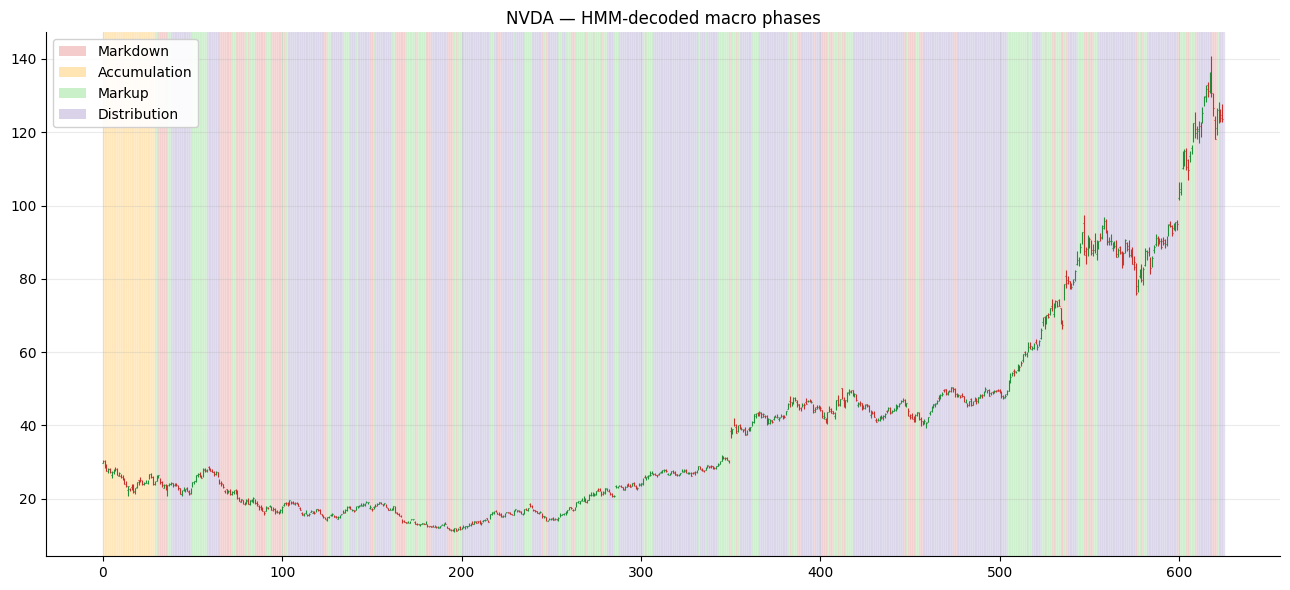

In [15]:
clf = WyckoffHMMClassifier(feature_window=30, n_init=3, max_iter=120, seed=42)
hmm = clf.fit_predict(bars)
print(f'log-likelihood = {hmm.log_likelihood:.1f}')
print(f'state -> label : {hmm.state_to_label}')

label_to_color = {
    'Markdown': '#F4CCCC',
    'Accumulation': '#FFE5B4',
    'Markup': '#C9F0C9',
    'Distribution': '#D9D2E9',
}
fig, ax = plt.subplots(figsize=(13, 6))
for i, lbl in enumerate(hmm.labels):
    ax.axvspan(i, i + 1, alpha=0.55, color=label_to_color[lbl])
plot_ohlc(ax, bars)
handles = [plt.Rectangle((0, 0), 1, 1, fc=c) for c in label_to_color.values()]
ax.legend(handles, list(label_to_color), loc='upper left', framealpha=0.9)
ax.set_title(f'{bars.symbol} — HMM-decoded macro phases')
plt.tight_layout()
plt.show()


## 9. Point-and-Figure & cause-and-effect targets

P&F charts strip out time and noise, keeping only directional moves of
at least one box. Each column is either an X (up) or O (down), and a
counter-column requires a `reversal`-box move.

Two counts produce price targets from the *Law of Cause and Effect*:

* **Vertical count** — column length × box × reversal,
  projected from the column's origin.
* **Horizontal count** — width of the base preceding a breakout
  × box × reversal, projected from the breakout level.


In [16]:
chart = pnf_from_bars(bars, reversal=3)
print(
    f'box size = {chart.box_size:.3f}   reversal = {chart.reversal}   '
    f'columns = {chart.n_columns}'
)

for k, col in enumerate(chart.columns):
    print(
        f'  col {k:2d}  {col.direction}  start bar {col.start_idx:4d}  '
        f'[{col.boxes_low:7.2f}, {col.boxes_high:7.2f}]  n_boxes={col.n_boxes}'
    )


box size = 0.690   reversal = 3   columns = 47
  col  0  O  start bar    0  [  22.53,   30.12]  n_boxes=12
  col  1  X  start bar   20  [  23.22,   26.67]  n_boxes=6
  col  2  O  start bar   28  [  21.84,   25.98]  n_boxes=7
  col  3  X  start bar   50  [  22.53,   28.05]  n_boxes=9
  col  4  O  start bar   64  [  16.31,   27.36]  n_boxes=17
  col  5  X  start bar  101  [  17.00,   19.07]  n_boxes=4
  col  6  O  start bar  110  [  14.93,   18.38]  n_boxes=6
  col  7  X  start bar  136  [  15.62,   19.07]  n_boxes=6
  col  8  O  start bar  163  [  11.48,   18.38]  n_boxes=11
  col  9  X  start bar  207  [  12.17,   17.69]  n_boxes=9
  col 10  O  start bar  245  [  14.24,   17.00]  n_boxes=5
  col 11  X  start bar  258  [  14.93,   39.79]  n_boxes=37
  col 12  O  start bar  358  [  37.72,   39.10]  n_boxes=3
  col 13  X  start bar  362  [  38.41,   43.24]  n_boxes=8
  col 14  O  start bar  370  [  41.17,   42.55]  n_boxes=3
  col 15  X  start bar  381  [  41.86,   47.38]  n_boxes=9
  col

Vertical count   target = 119.18  (down, count=3)
Horizontal count target = 119.18  (down, base width=3)


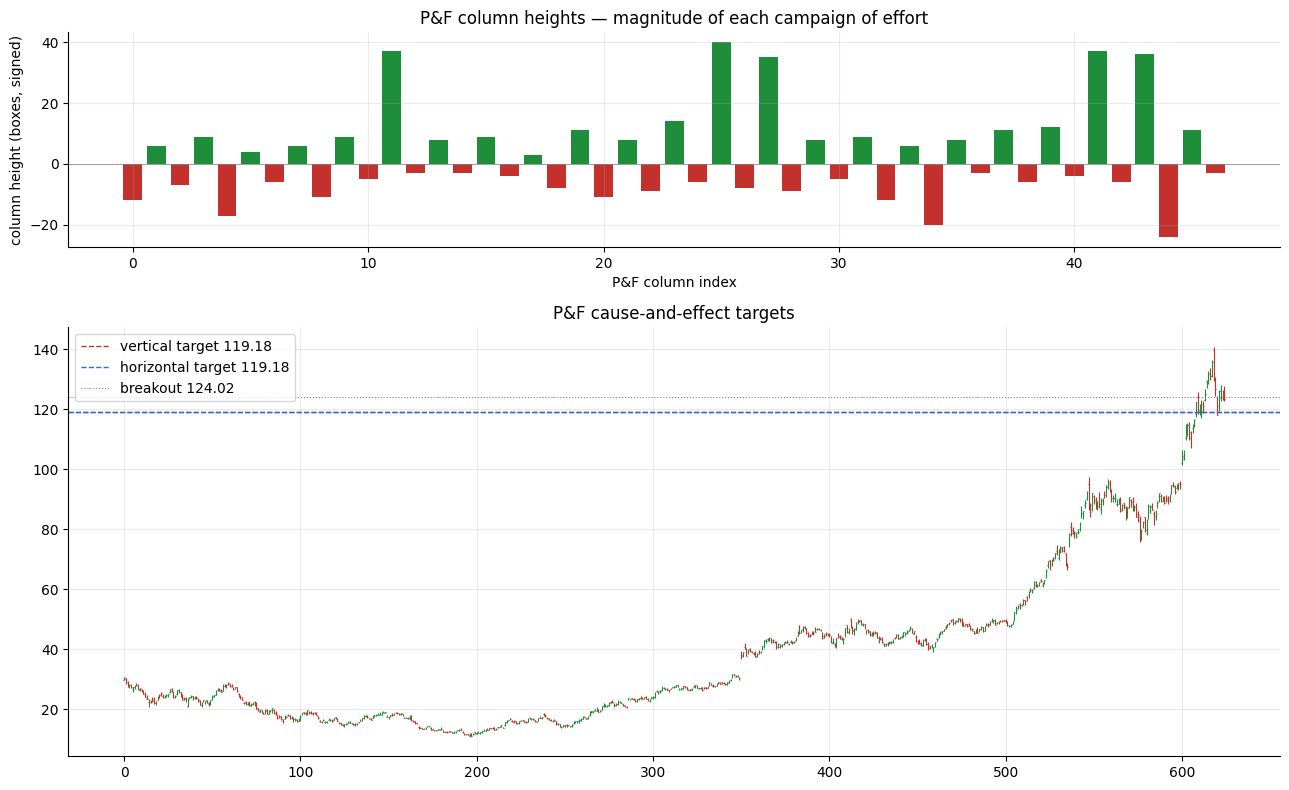

In [17]:
breakout_col = chart.n_columns - 1
vt = vertical_count(chart, column_idx=breakout_col)
ht = horizontal_count(chart, column_idx=breakout_col)
print(
    f'Vertical count   target = {vt.projected_price:.2f}  '
    f'({vt.direction}, count={vt.count_boxes})'
)
print(
    f'Horizontal count target = {ht.projected_price:.2f}  '
    f'({ht.direction}, base width={ht.count_boxes})'
)

# Bar chart of column heights, signed by direction — a literal
# visualisation of “cause” (the side-to-side width) and
# “effect” (the height of the eventual thrust column).
heights = np.array([
    col.n_boxes if col.direction == 'X' else -col.n_boxes for col in chart.columns
])
col_colors = [COLOR_UP if col.direction == 'X' else COLOR_DN for col in chart.columns]

fig, (ax_cols, ax_px) = plt.subplots(2, 1, figsize=(13, 8), height_ratios=[1, 2])
ax_cols.bar(np.arange(chart.n_columns), heights, color=col_colors, width=0.8)
ax_cols.axhline(0, color='gray', lw=0.5)
ax_cols.set_xlabel('P&F column index')
ax_cols.set_ylabel('column height (boxes, signed)')
ax_cols.set_title('P&F column heights — magnitude of each campaign of effort')

plot_ohlc(ax_px, bars)
ax_px.axhline(vt.projected_price, color=COLOR_DN, ls='--', lw=1.0,
              label=f'vertical target {vt.projected_price:.2f}')
ax_px.axhline(ht.projected_price, color='#1f6feb', ls='--', lw=1.0,
              label=f'horizontal target {ht.projected_price:.2f}')
ax_px.axhline(vt.breakout_price, color='gray', ls=':', lw=0.8,
              label=f'breakout {vt.breakout_price:.2f}')
ax_px.legend(loc='upper left')
ax_px.set_title('P&F cause-and-effect targets')
plt.tight_layout()
plt.show()


## 10. Wyckoff-style relative strength

A stock is *Wyckoff-strong* if its price holds up or rises against its
benchmark during the benchmark's weakness. `relative_strength` is the
(optionally rebased) `asset / benchmark` ratio; `rs_rank` returns a
cross-sectional rolling rank in `[0, 1]`.

We compare a handful of large-caps against SPY over the same window.


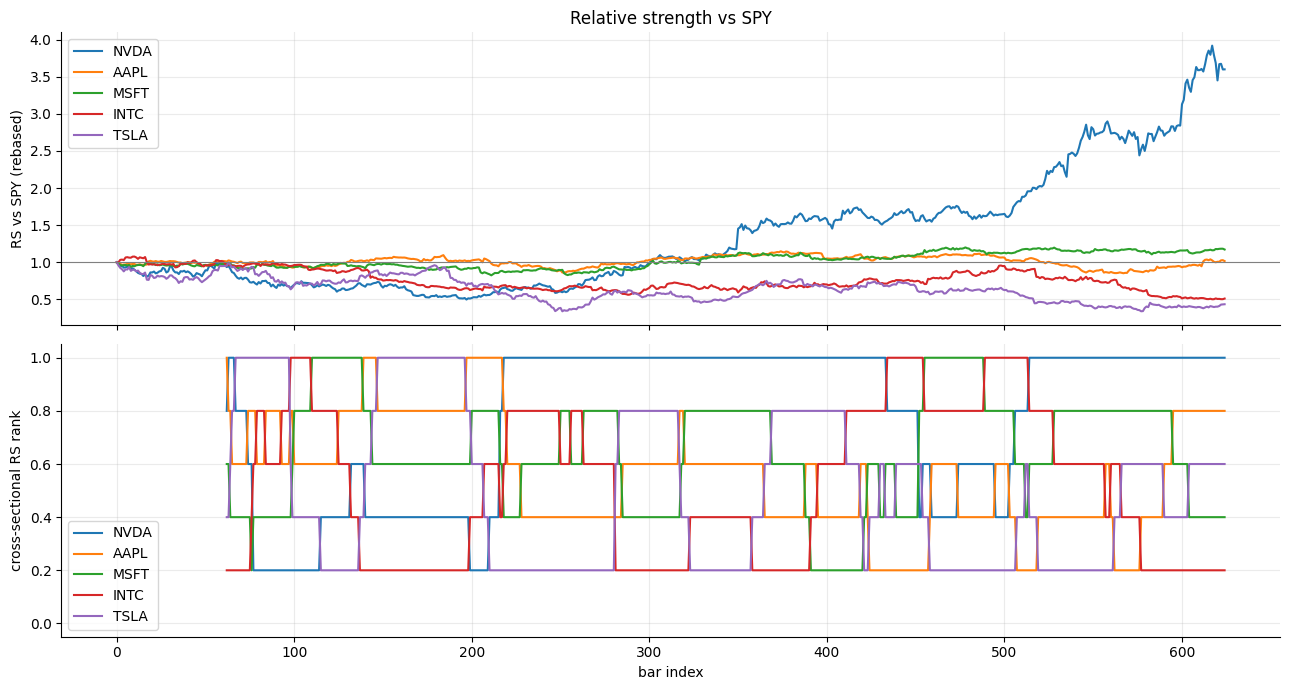

In [18]:
universe_tickers = ('NVDA', 'AAPL', 'MSFT', 'INTC', 'TSLA')
bench_ticker = 'SPY'
rs_start, rs_end = '2022-01-01', '2024-07-01'

bench_bars = load_ohlcv(bench_ticker, rs_start, rs_end)
universe_bars = {t: load_ohlcv(t, rs_start, rs_end) for t in universe_tickers}


def align_close(b: OHLCV) -> np.ndarray:
    """Forward-fill ``b.close`` onto the benchmark's timestamp grid."""
    joined = (
        bench_bars.data.select('timestamp')
        .join(b.data.select(['timestamp', 'close']),
              on='timestamp', how='left')
        .with_columns(pl.col('close').forward_fill())
    )
    return joined['close'].to_numpy().astype(np.float64)


bench_close = bench_bars.close()
universe_close = {t: align_close(b) for t, b in universe_bars.items()}

rs = {t: relative_strength(p, bench_close) for t, p in universe_close.items()}
ranks = rs_rank(universe_close, bench_close, window=63)

fig, (ax_rs, ax_rk) = plt.subplots(2, 1, sharex=True, figsize=(13, 7))
for sym, series in rs.items():
    ax_rs.plot(series, label=sym)
ax_rs.axhline(1.0, color='gray', lw=0.8)
ax_rs.set_ylabel(f'RS vs {bench_ticker} (rebased)')
ax_rs.legend(loc='upper left')
ax_rs.set_title(f'Relative strength vs {bench_ticker}')

for sym, series in ranks.items():
    ax_rk.plot(series, label=sym)
ax_rk.set_ylabel('cross-sectional RS rank')
ax_rk.set_xlabel('bar index')
ax_rk.set_ylim(-0.05, 1.05)
ax_rk.legend(loc='lower left')
plt.tight_layout()
plt.show()


## What to do next

* Swap NVDA for any other yfinance ticker, or point `load_ohlcv` at your
  own Parquet/CSV. Every detector in this notebook operates on the same
  `OHLCV` interface.
* Tune the detector thresholds (`z_volume`, `z_range`,
  `max_penetration_atr`, `recovery_bars`, …) for your asset and
  timeframe; the defaults are tuned for daily liquid US equities.
* Combine the HMM macro overlay with the rule-based phase classifier
  for a two-tier view: the HMM picks the regime; the rule classifier
  dissects each accumulation/distribution range.
* Use `effort_vs_result` as a continuous feature in a model rather than
  a binary flag — `divergence = z_effort - z_result` is informative
  on its own.
* For higher-frequency work, resample with
  `qufin.wyckoff.resample(bars, '1h')` or `'1w'` and re-run the same
  pipeline on the new timeframe.
